# Chapter 10 — Bet Sizing

Implements AFML Snippets 10.1–10.4 (López de Prado): translating classifier
probabilities into bet sizes, averaging concurrently active bets,
discretizing to prevent overtrading, and dynamic position sizing against a
limit price. Runs end-to-end on the real 88-row BTC/TUSD triple-barrier
table (Chapters 3–5), using Chapter 9's real winning SVC hyperparameters.

## 10.1–10.3 — Why a probability isn't a bet size

A classifier's predicted probability tells you how confident it is, but not
directly how large a position to take. AFML's approach: test the
probability against the null hypothesis that all outcomes are equally
likely (probability = 1/numClasses). The further the probability sits from
that null, the more confident the prediction — and the larger the bet.

For two classes, with predicted-class probability $p$:

$$z = \frac{p - \tfrac{1}{2}}{\sqrt{p(1-p)}}, \qquad m = \text{side} \times (2\Phi(z) - 1)$$

where $\Phi$ is the standard normal CDF. $m \in [-1, 1]$ is the raw bet
size, signed by the predicted side.

Two more steps before this is usable:
1. **Average concurrently active bets** (Snippet 10.2) — if two bets are
   open at the same time, blend them rather than letting the newer one
   silently overwrite the older one's information.
2. **Discretize** (Snippet 10.3) — round to a step size and cap at ±1, so
   the position doesn't get re-sized on every marginal probability wiggle.

### Worked numerical example

Before running this on real data, a hand-traced example to confirm the
math (this is also pinned as a TDD test in `test_bet_sizing.py`):

- $p = 0.7$, numClasses = 2, predicted side = $+1$
- $z = (0.7 - 0.5) / \sqrt{0.7 \times 0.3} = 0.2 / 0.4583 = 0.4364$
- $m = 1 \times (2\Phi(0.4364) - 1) = 1 \times (2 \times 0.6687 - 1) = 0.3375$
- Discretized to stepSize = 0.01 → **0.34**

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ---------------------------------------------------------------------------
# EDIT THIS ONE LINE FOR YOUR MACHINE, then run the notebook.
# Notebooks cannot reliably use __file__ or cwd -- Jupyter's working directory
# is not dependably the notebook's own folder (a confirmed problem on this
# project's machine), which is why the repo convention is a single hardcoded
# root here rather than a derived one. See CLAUDE.md.
AFML_ROOT = r'C:\ws\AFML'
# ---------------------------------------------------------------------------

sys.path.insert(0, os.path.join(AFML_ROOT, 'ch10', 'bet_sizing'))
from bet_sizing import getSignal, discreteSignal, betSize, getTPos, invPrice, limitPrice, getW
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch07', 'cross_validation'))
from purged_kfold import PurgedKFold

# Confirm the worked example above matches the code
p, num_classes, pred_side = 0.7, 2, 1
z = (p - 1./num_classes) / (p*(1.-p))**.5
m = pred_side * (2*norm.cdf(z) - 1)
print(f'z = {z:.4f}, raw m = {m:.4f}, discretized (step=0.01) = {discreteSignal(pd.Series([m]), 0.01).iloc[0]:.2f}')

z = 0.4364, raw m = 0.3375, discretized (step=0.01) = 0.34


## Loading the real data

The real Ch03–05 BTC/TUSD triple-barrier table: `fracdiff` (feature),
`bin` (label, ∈ {-1, 1}), `w` (Ch04 sample-uniqueness weight), `t1`
(label end time — this is what Snippet 10.2's concurrency averaging needs).

In [2]:
INPUT_DIR = os.path.join(AFML_ROOT, 'input_data')

# Since 2026-07-21 this loads the ENRICHED training table: 87 events x 12
# features (fracdiff + Ch19's 11 microstructural features), not the original
# 88-event fracdiff-only table. Before that change the pipeline alternated --
# Ch09 enriched, Ch10 thin, Ch11 thin, Ch12/Ch14 enriched -- leaving this
# chapter a single-feature island whose results were not comparable with the
# chapters either side of it. (Ch07 deliberately stays on the thin table: it
# is chapter 7, and the enrichment is built by chapter 19, so pointing it here
# would be a forward dependency that breaks book order.)
table = pd.read_csv(os.path.join(INPUT_DIR, 'ch07_training_table_enriched.csv'),
                     index_col=0, parse_dates=[0, 't1'])
print(table.shape)
table.head()

(87, 15)


,fracdiff,roll_c,roll_sigma_u,parkinson_vol_20bar,corwin_schultz_spread,becker_parkinson_sigma,kyle_lambda,amihud_lambda_20bar,vpin_10bar,round_number_fraction,serial_corr_signed_flow,tick_rule_accuracy,bin,w,t1
2026-03-02 15:30:49.837102,6.003580,74.752815,508.617564,0.005125,0.000056,0.016558,2760.300927,1.727344e-07,0.850329,0.000000,0.250160,0.596491,1.0,7.344949,2026-03-02 16:46:56.199924
2026-03-02 16:46:56.199924,6.017582,0.000000,806.751710,0.006243,0.000000,0.037540,7263.303197,2.411215e-07,0.768858,0.014286,0.622261,0.671429,-1.0,0.341358,2026-03-02 19:00:58.984721
2026-03-02 19:00:58.984721,5.993668,0.000000,736.711030,0.006747,0.015182,0.005036,3644.283913,3.655416e-07,0.693888,0.020000,0.156092,0.700000,-1.0,2.939428,2026-03-03 09:28:01.084240
2026-03-03 03:09:58.655387,5.985434,0.000000,751.682724,0.007084,0.000000,0.012472,369.159023,4.434961e-07,0.512477,0.021277,0.348155,0.702128,-1.0,2.212135,2026-03-03 09:28:01.084240
2026-03-03 09:28:01.084240,5.960179,0.000000,895.086423,0.007910,0.000000,0.012236,5137.073074,4.961354e-07,0.899676,0.016949,0.446164,0.711864,1.0,0.153364,2026-03-04 00:23:40.276445


## Getting real probabilities: why out-of-sample matters

`getSignal` needs a classifier's `predict_proba` output. Chapter 9 already
found the best SVC hyperparameters for this exact dataset — `C=100,
gamma=0.1`, the real-data grid-search winner scored on `neg_log_loss` — but
only the winning hyperparameters were saved (`ch09_hyperparameter_tuning_stats.pkl`),
not a fitted model object.

**Refitting is the right move here, not a workaround** — but refitting
*in-sample* (fit and predict on the same rows) would be lookahead bias: the
bet-sizing signal would be informed by data the classifier was trained on,
including observations that happened after the very bet being sized.

Chapter 7's `PurgedKFold` (already calibrated for this dataset —
`n_splits=4, pctEmbargo=0.12`) fixes this: each observation gets a
probability from a fold that never trained on it, with training
observations whose label window overlaps the test set purged, and a
further embargo window dropped for serial correlation. This is the same
mechanism Ch07/Ch09 already use for honest cross-validation scores —
applying it here for out-of-sample signal generation is a straight extension
of a rule you've already established for this repo, not a new idea.

In [3]:
N_SPLITS = 4          # matches Ch07's real-data calibration for this dataset
PCT_EMBARGO = 0.12     # matches Ch07's real-data calibration for this dataset
# 0.01, not the 100.0 this cell used before 2026-07-21. Ch09's grid optimum
# moved four orders of magnitude once the enriched table replaced the
# single-feature one -- heavier regularization is exactly what you expect from
# 12 correlated features on 87 rows. C is tuned FOR a dataset, so this constant
# and the loader above are one decision, not two.
# PRECONDITION: 0.01 is only meaningful inside the StandardScaler pipeline
# below, because Ch09 tuned it on scaled features.
SVC_C = 0.01           # Ch09's real-data grid-search winner (neg_log_loss)
SVC_GAMMA = 0.1        # Ch09's real-data grid-search winner (neg_log_loss)
STEP_SIZE = 0.01

def out_of_sample_probs(X, y, w, t1, n_splits=N_SPLITS, pct_embargo=PCT_EMBARGO,
                         C=SVC_C, gamma=SVC_GAMMA, random_state=0):
    """Per-fold fit + predict_proba via PurgedKFold -- no grid search, no
    joblib parallelism, so the Windows SVC(probability=True)+loky crash risk
    from the Ch09 handoff doesn't apply here, but staying single-threaded
    regardless.

    random_state is required: SVC(probability=True) fits an internal
    randomized 5-fold CV (Platt scaling) to calibrate predict_proba.
    Without it, predict/predict_proba are non-deterministic run-to-run --
    confirmed empirically to flip which class wins on this small,
    single-feature dataset between sklearn 1.2.2 (real machine) and a
    later sklearn (sandbox). Pinning random_state=0 fixes this."""
    gen = PurgedKFold(n_splits=n_splits, t1=t1, pctEmbargo=pct_embargo)
    prob = pd.Series(index=X.index, dtype=float)
    pred = pd.Series(index=X.index, dtype=float)
    for train, test in gen.split(X=X):
        # The StandardScaler wrapper is LOAD-BEARING (added 2026-07-21, the
        # same fix Ch09 and Ch12 already carry). A bare SVC on raw X was
        # harmless while X was one fracdiff column. On the enriched table the
        # feature magnitudes span about 3.8e9 to 1 -- kyle_lambda averages
        # ~2.4e3 next to amihud_lambda_20bar at ~6.3e-07 -- and an unscaled
        # RBF kernel's squared distance is then set almost entirely by the
        # largest-magnitude column, so the other ten features stop
        # contributing. The result is a near-useless fit that still returns
        # plausible-looking probabilities, which is the dangerous kind of
        # wrong. The scaler is refit per fold on the TRAINING fold only, so no
        # test-fold statistics leak.
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('svc', SVC(C=C, gamma=gamma, probability=True,
                        random_state=random_state)),
        ])
        pipe.fit(X.iloc[train, :], y.iloc[train],
                 svc__sample_weight=w.iloc[train].values)
        proba = pipe.predict_proba(X.iloc[test, :])
        idx_max = proba.argmax(axis=1)
        prob.iloc[test] = proba[np.arange(len(test)), idx_max]
        pred.iloc[test] = pipe.named_steps['svc'].classes_[idx_max]
    return prob, pred

# All feature columns, not a hardcoded [['fracdiff']] -- matching Ch09/Ch12,
# so an upstream feature addition can never silently bypass this chapter again.
feature_cols = [c for c in table.columns if c not in ('bin', 'w', 't1')]
X = table[feature_cols]
print(f'training table: {X.shape[0]} events x {X.shape[1]} features')
y = table['bin']
w = table['w']
t1 = table['t1']
events = table[['t1']]

prob, pred = out_of_sample_probs(X, y, w, t1)
pd.DataFrame({'prob': prob, 'pred': pred}).describe()

training table: 87 events x 12 features


,prob,pred
count,87.000000,87.000000
mean,0.570998,0.402299
std,0.053984,0.920816
min,0.500000,-1.000000
25%,0.525596,-1.000000
50%,0.573080,1.000000
75%,0.576761,1.000000
max,0.749988,1.000000


## Running the full 10.1–10.3 pipeline on real data

In [4]:
signal = getSignal(events, stepSize=STEP_SIZE, prob=prob, pred=pred,
                    numClasses=2, numThreads=1)
print(signal.describe())
signal.value_counts().sort_index()

count    105.000000
mean       0.064667
std        0.083931
min       -0.120000
25%        0.000000
50%        0.080000
75%        0.120000
max        0.250000
dtype: float64


-0.12     1
-0.10     1
-0.08     1
-0.06     4
-0.05     5
-0.04     3
-0.03     5
-0.02     2
-0.01     4
 0.00     5
 0.01     4
 0.02     8
 0.03     4
 0.04     2
 0.07     3
 0.08     1
 0.10     2
 0.11     1
 0.12    27
 0.13     5
 0.14     4
 0.15     3
 0.16     1
 0.18     3
 0.19     1
 0.20     1
 0.21     1
 0.24     2
 0.25     1
dtype: int64

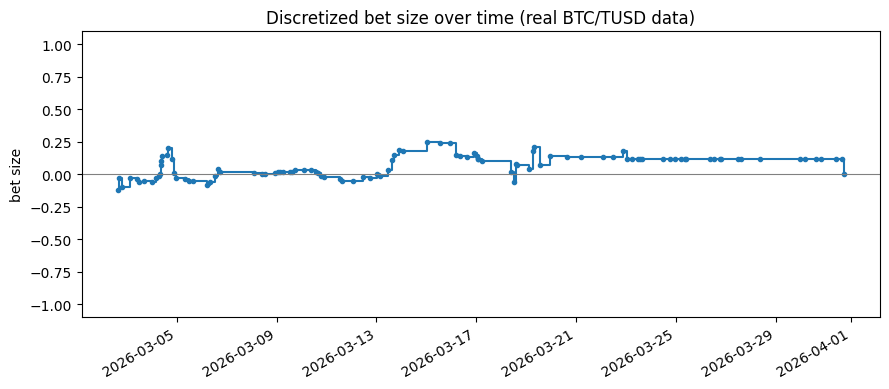

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
signal.sort_index().plot(ax=ax, drawstyle='steps-post', marker='o', markersize=3)
ax.set_title('Discretized bet size over time (real BTC/TUSD data)')
ax.set_ylabel('bet size')
ax.set_ylim(-1.1, 1.1)
ax.axhline(0, color='gray', linewidth=0.8)
fig.tight_layout()
plt.show()

**Reading these results:** bet sizes here are modest (mostly under 0.25
in magnitude). That tracks with the probabilities above sitting close to
the null (mostly 0.55–0.65, not far from the 0.5 equal-likelihood line for
a 2-class problem) — a weak-but-real signal, not a strong one.

**(Updated 2026-07-22.)** This paragraph previously attributed the weak
signal to the training table having only one feature (`fracdiff`), per
the "recurring theme" flagged at the end of the Ch09 handoff. Since then,
Ch19's enrichment added 11 more real microstructural features (12 total,
as shown above) specifically to test that theory — and the weak signal
persisted. This is now understood as a genuine finding, not a
thin-feature artifact: Ch11's PBO (~0.83), Ch12's CPCV (all 5 real paths
negative), and Ch14's DSR (0/5 paths survive) independently corroborate
that this feature set/model combination carries little real, exploitable
signal on this data. The bet-sizing math is doing exactly what it should
here — sizing down when the signal is weak, rather than manufacturing
false confidence.

## 10.4 — Dynamic position sizing and limit price

A different mechanism from 10.1–10.3: instead of sizing from a
classifier's probability, size from the **divergence** between a forecast
price $f$ and the current market price. Bet size follows a sigmoid-like
curve in the divergence $x = f - \text{marketPrice}$, calibrated by $w$:

$$\text{betSize}(w, x) = \frac{x}{\sqrt{w + x^2}}$$

$w$ is calibrated once via `getW(x, m)`, from a chosen (divergence, target
bet size) pair — e.g. "at a \$10 divergence, I want a 95% bet size." The
book's own demo (Snippet 10.4 `main()`) does exactly this.

In [6]:
# Book's own Snippet 10.4 demo values
pos, maxPos, mP, f = 0, 100, 100, 115
w = getW(10, .95)
print(f'w = {w}')

tPos = getTPos(w, f, mP, maxPos)
print(f'target position = {tPos}')

lP = limitPrice(tPos, pos, f, w, maxPos)
print(f'limit price = {lP:.4f}')

# Confirm the calibration: betSize(w, 10) should be exactly 0.95
print(f'betSize(w, 10) = {betSize(w, 10):.4f} (should be 0.95)')

w = 10.803324099723
target position = 97
limit price = 112.3657
betSize(w, 10) = 0.9500 (should be 0.95)


## Book-fidelity notes

- `getSignal`/`avgActiveSignals` dispatch through this repo's
  `utils/multiprocess.py:mp_pandas_obj` (snake_case reimplementation of the
  book's `mpPandasObj`, established Ch04+) — molecule handling and kwarg
  passing unchanged.
- `limitPrice` used Python 2's `xrange` in the printed snippet; replaced
  with `range` for Python 3.10 — no semantic change.
- All other lines match the printed snippets 10.1–10.4. The two-class and
  one-vs-rest z-statistic derivations were checked against the book's
  Section 10.3 text and match exactly (see worked example above).

## TDD results

13/13 tests pass in `test_bet_sizing.py` (known expected values hand-traced
from the book's own formulas — see the module for the full pytest output
embedded as comments). Confirmed on the real `mlfinlab` env (Python
3.10.20 / pandas 1.5.3 / sklearn 1.2.2) via `chapter_10_bet_sizing.py` —
see project chat, July 2026.

**One real bug surfaced by that real-machine run, not caught in sandbox:**
`SVC(probability=True)` without a pinned `random_state` is
non-deterministic (its internal Platt-scaling CV), and the real machine's
sklearn 1.2.2 produced a different `pred` distribution than this
notebook's sandbox sklearn on this small, single-feature dataset — flipped
which class won entirely. Fixed by pinning `random_state=0`; verified
reproducible across repeated runs after the fix.

### TDD results (`test_bet_sizing.py`)

All 13 tests pass (sandbox: Python 3.12.3, pandas 3.0.2, scipy 1.17.1,
numpy 2.4.4). Confirmed on the real `mlfinlab` env (Python 3.10.20 /
pandas 1.5.3 / sklearn 1.2.2) via this notebook's real-data run -- see
project chat, July 2026.

```
============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-9.1.1, pluggy-1.6.0
collected 13 items

tests/test_bet_sizing.py::TestDiscreteSignal::test_rounds_to_stepSize PASSED
tests/test_bet_sizing.py::TestDiscreteSignal::test_caps_at_plus_one PASSED
tests/test_bet_sizing.py::TestDiscreteSignal::test_floors_at_minus_one PASSED
tests/test_bet_sizing.py::TestMpAvgActiveSignals::test_two_overlapping_bets_averaged PASSED
tests/test_bet_sizing.py::TestMpAvgActiveSignals::test_no_active_bets_returns_zero PASSED
tests/test_bet_sizing.py::TestMpAvgActiveSignals::test_open_ended_bet_NaT_stays_active PASSED
tests/test_bet_sizing.py::TestAvgActiveSignalsEmptyEdgeCase::test_empty_signals_returns_empty_dataframe_not_series PASSED
tests/test_bet_sizing.py::TestGetSignal::test_single_bet_two_class_known_value PASSED
tests/test_bet_sizing.py::TestGetSignal::test_empty_prob_returns_empty_series PASSED
tests/test_bet_sizing.py::TestGetSignal::test_meta_labeling_side_flips_signal PASSED
tests/test_bet_sizing.py::TestDynamicSizing::test_getW_calibrates_betSize_to_target PASSED
tests/test_bet_sizing.py::TestDynamicSizing::test_book_demo_values PASSED
tests/test_bet_sizing.py::TestDynamicSizing::test_invPrice_inverts_betSize PASSED

============================== 13 passed in 1.11s ===============================
```

**Fixes applied after the real-machine run surfaced them** (not book-snippet
bugs -- environment/determinism issues in the demo pipeline around this
module): empty `pd.Series()` calls now specify `dtype=float` explicitly
(pandas `FutureWarning` guard), and `chapter_10_bet_sizing.py`'s
`SVC(probability=True)` pins `random_state=0` -- without it, `predict_proba`'s
internal Platt-scaling CV is non-deterministic and differed enough between
sklearn 1.2.2 (real machine) and sklearn 1.8.0 (sandbox) to flip which class
won on this small, single-feature dataset.
